In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
import warnings 

warnings.filterwarnings('ignore')   


### Plot Styling 

In [4]:
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


### Load and Preview the Data 

In [7]:
from pathlib import Path

DATA_PATH = Path('../data/raw/HHS_Unaccompanied_Alien_Children_Program.csv')

In [8]:
df = pd.read_csv(DATA_PATH)

print("===FIRST 5 ROWS OF THE DATASET===")
print(df.head())

===FIRST 5 ROWS OF THE DATASET===
                Date  Children apprehended and placed in CBP custody*  \
0  December 21, 2025                                              6.0   
1  December 18, 2025                                             11.0   
2  December 17, 2025                                              7.0   
3  December 16, 2025                                              8.0   
4  December 15, 2025                                             11.0   

   Children in CBP custody  Children transferred out of CBP custody  \
0                     18.0                                     11.0   
1                     50.0                                      6.0   
2                     31.0                                     11.0   
3                     54.0                                     15.0   
4                     42.0                                      9.0   

  Children in HHS Care  Children discharged from HHS Care  
0                2,484                  

In [9]:
print("\n=== LAST 5 ROWS ===")
print(df.tail())

# Shape
print(f"\n=== SHAPE ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# Column names
print(f"\n=== COLUMN NAMES ===")
for i, col in enumerate(df.columns):
    print(f"  {i+1}. {col}")



=== LAST 5 ROWS ===
     Date  Children apprehended and placed in CBP custody*  \
1165  NaN                                              NaN   
1166  NaN                                              NaN   
1167  NaN                                              NaN   
1168  NaN                                              NaN   
1169  NaN                                              NaN   

      Children in CBP custody  Children transferred out of CBP custody  \
1165                      NaN                                      NaN   
1166                      NaN                                      NaN   
1167                      NaN                                      NaN   
1168                      NaN                                      NaN   
1169                      NaN                                      NaN   

     Children in HHS Care  Children discharged from HHS Care  
1165                  NaN                                NaN  
1166                  NaN          

### Clean the Data 

In [10]:
# Step 1: Rename columns to short clean names
df.columns = [
    'Date',
    'CBP_Apprehended',
    'CBP_Custody',
    'CBP_Transferred',
    'HHS_Care',
    'HHS_Discharged'
]

# Step 2: Drop rows where all values are NaN (blank padding rows)
df = df.dropna(how='all').reset_index(drop=True)

# Step 3: Parse Date column properly
df['Date'] = pd.to_datetime(df['Date'])

# Step 4: Clean numeric columns — remove commas and asterisks, convert to numbers
numeric_cols = ['CBP_Apprehended', 'CBP_Custody', 'CBP_Transferred', 
                'HHS_Care', 'HHS_Discharged']

for col in numeric_cols:
    df[col] = df[col].astype(str).str.replace(',', '').str.replace('*', '').str.strip()
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Step 5: Sort by date oldest to newest
df = df.sort_values('Date').reset_index(drop=True)

# Confirm
print(f"Shape after cleaning: {df.shape}")
print(f"Date range: {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Missing values:\n{df.isnull().sum()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nFirst 3 rows after cleaning:")
print(df.head(3))

Shape after cleaning: (720, 6)
Date range: 2023-01-12 → 2025-12-21
Missing values:
Date               0
CBP_Apprehended    0
CBP_Custody        0
CBP_Transferred    0
HHS_Care           0
HHS_Discharged     0
dtype: int64

Data types:
Date               datetime64[ns]
CBP_Apprehended           float64
CBP_Custody               float64
CBP_Transferred           float64
HHS_Care                    int64
HHS_Discharged            float64
dtype: object

First 3 rows after cleaning:
        Date  CBP_Apprehended  CBP_Custody  CBP_Transferred  HHS_Care  \
0 2023-01-12             33.0         53.0             34.0      6566   
1 2023-01-22             32.0         49.0             39.0      7122   
2 2023-01-23             32.0         50.0             39.0      7280   

   HHS_Discharged  
0           436.0  
1           227.0  
2           181.0  


### Descriptive statistics 

In [11]:
print("=== DESCRIPTIVE STATISTICS ===\n")
print(df.describe().round(2))

print("\n=== ADDITIONAL STATS ===\n")

numeric_cols = ['CBP_Apprehended', 'CBP_Custody', 'CBP_Transferred', 
                'HHS_Care', 'HHS_Discharged']

for col in numeric_cols:
    print(f"--- {col} ---")
    print(f"  Mean   : {df[col].mean():.2f}")
    print(f"  Median : {df[col].median():.2f}")
    print(f"  Std Dev: {df[col].std():.2f}")
    print(f"  Min    : {df[col].min():.2f}")
    print(f"  Max    : {df[col].max():.2f}")
    print(f"  Skew   : {df[col].skew():.2f}")
    print()

=== DESCRIPTIVE STATISTICS ===

                                Date  CBP_Apprehended  CBP_Custody  \
count                            720           720.00       720.00   
mean   2024-07-06 05:29:59.999999744            93.52       171.49   
min              2023-01-12 00:00:00             0.00         7.00   
25%              2023-10-16 18:00:00            12.00        36.00   
50%              2024-07-05 12:00:00            99.00       193.00   
75%              2025-03-25 06:00:00           147.25       263.25   
max              2025-12-21 00:00:00           333.00       531.00   
std                              NaN            72.65       126.35   

       CBP_Transferred  HHS_Care  HHS_Discharged  
count           720.00    720.00          720.00  
mean            128.67   6061.28          173.41  
min               0.00   1972.00            0.00  
25%              14.00   2467.75           19.75  
50%             157.00   6406.50          181.00  
75%             199.25   8010.2

### Data Continuity Check 

In [12]:
# Add helper columns
df['Year']    = df['Date'].dt.year
df['Month']   = df['Date'].dt.month
df['Weekday'] = df['Date'].dt.day_name()

# Calculate gap between each consecutive date
df['Date_Gap'] = df['Date'].diff().dt.days

# Find all gaps greater than 3 days (weekends = 2-3 days, so >3 flags real gaps)
gaps = df[df['Date_Gap'] > 3][['Date', 'Date_Gap']].copy()
gaps['Previous_Date'] = df['Date'].shift(1)
gaps = gaps[['Previous_Date', 'Date', 'Date_Gap']].reset_index(drop=True)

print(f"=== DATE CONTINUITY CHECK ===\n")
print(f"Total records       : {len(df)}")
print(f"Date range          : {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Calendar days spanned: {(df['Date'].max() - df['Date'].min()).days}")
print(f"Gaps > 3 days found : {len(gaps)}")

print(f"\n=== ALL GAPS > 3 DAYS ===")
print(gaps.to_string(index=False))

print(f"\n=== RECORDS PER YEAR ===")
print(df['Year'].value_counts().sort_index())

print(f"\n=== RECORDS PER WEEKDAY ===")
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
print(df['Weekday'].value_counts().reindex(weekday_order))

=== DATE CONTINUITY CHECK ===

Total records       : 720
Date range          : 2023-01-12 → 2025-12-21
Calendar days spanned: 1074
Gaps > 3 days found : 29

=== ALL GAPS > 3 DAYS ===
Previous_Date       Date  Date_Gap
   2023-01-12 2023-01-22      10.0
   2023-01-25 2023-01-29       4.0
   2023-02-16 2023-02-20       4.0
   2023-03-02 2023-03-07       5.0
   2023-03-09 2023-03-13       4.0
   2023-05-25 2023-05-29       4.0
   2023-06-15 2023-06-19       4.0
   2023-08-10 2023-08-16       6.0
   2023-08-31 2023-09-04       4.0
   2023-10-05 2023-10-09       4.0
   2023-11-08 2023-11-12       4.0
   2023-12-21 2023-12-25       4.0
   2023-12-28 2024-01-01       4.0
   2024-01-11 2024-01-15       4.0
   2024-02-15 2024-02-19       4.0
   2024-05-23 2024-05-27       4.0
   2024-07-17 2024-07-21       4.0
   2024-08-22 2024-08-27       5.0
   2024-08-29 2024-09-02       4.0
   2024-10-03 2024-10-07       4.0
   2024-10-23 2024-10-27       4.0
   2024-11-07 2024-11-11       4.0
   2025-02-1

### Distribution Plots (Histograms) 

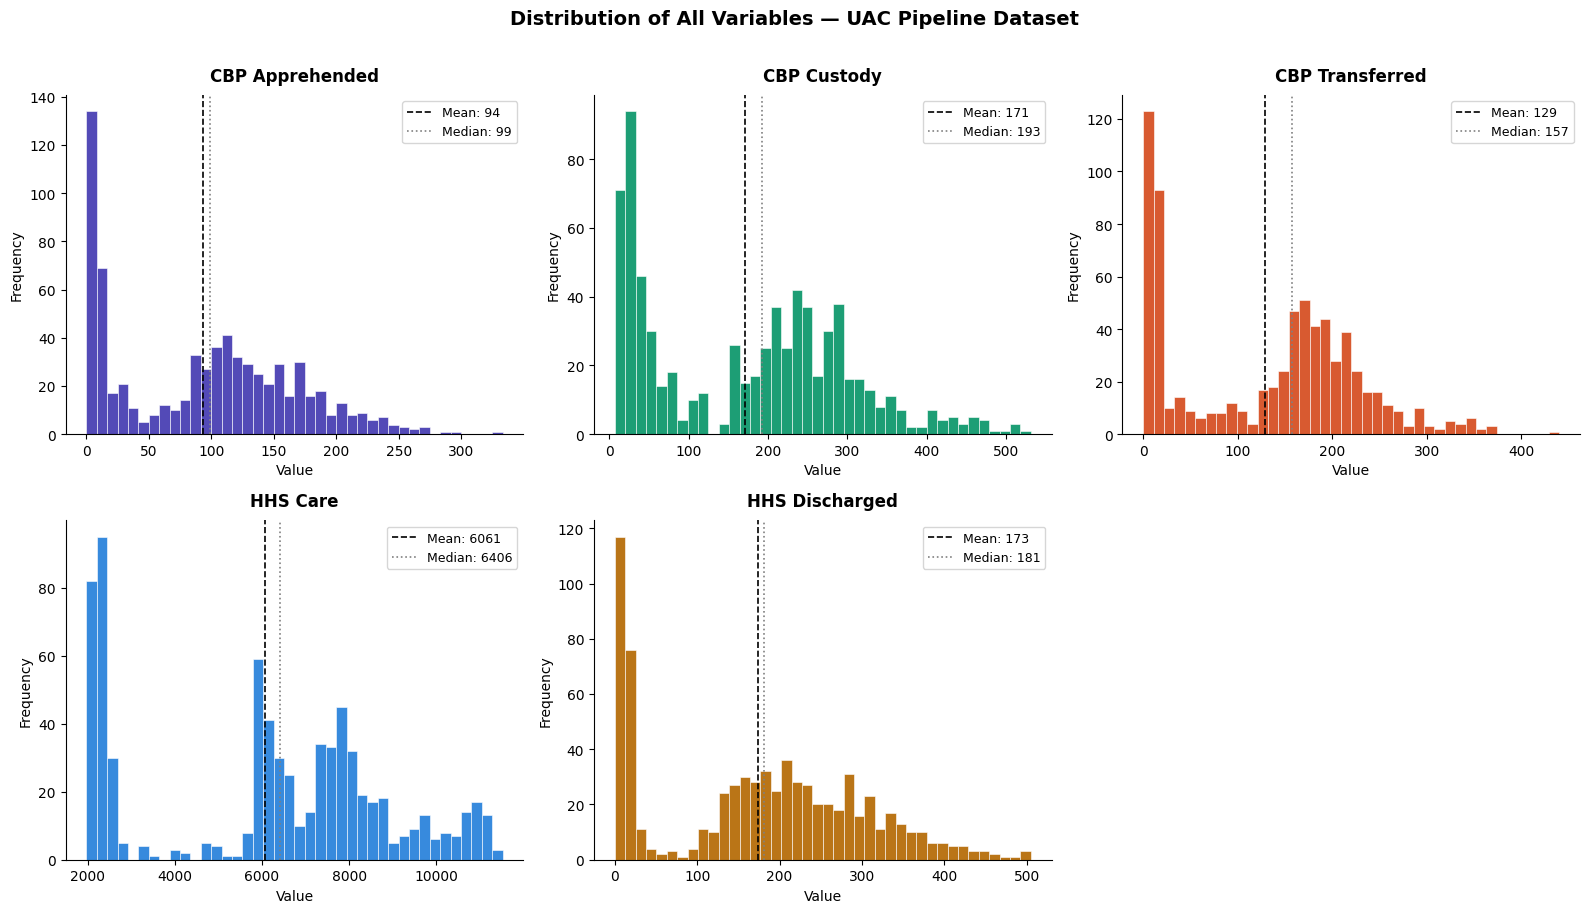

Distribution plots saved to assets/charts/


In [17]:
numeric_cols = ['CBP_Apprehended', 'CBP_Custody', 'CBP_Transferred', 
                'HHS_Care', 'HHS_Discharged']

col_colors = {
    'CBP_Apprehended' : '#534AB7',
    'CBP_Custody'     : '#1D9E75',
    'CBP_Transferred' : '#D85A30',
    'HHS_Care'        : '#378ADD',
    'HHS_Discharged'  : '#BA7517'
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    ax.hist(df[col], bins=40, color=col_colors[col], edgecolor='white', linewidth=0.4)
    ax.axvline(df[col].mean(),   color='black', linestyle='--', linewidth=1.2, label=f'Mean: {df[col].mean():.0f}')
    ax.axvline(df[col].median(), color='gray',  linestyle=':',  linewidth=1.2, label=f'Median: {df[col].median():.0f}')
    ax.set_title(col.replace('_', ' '), fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Value', fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Hide the 6th empty subplot
axes[5].set_visible(False)

fig.suptitle('Distribution of All Variables — UAC Pipeline Dataset', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../assets/charts/01_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("Distribution plots saved to assets/charts/")

### Boxplots 

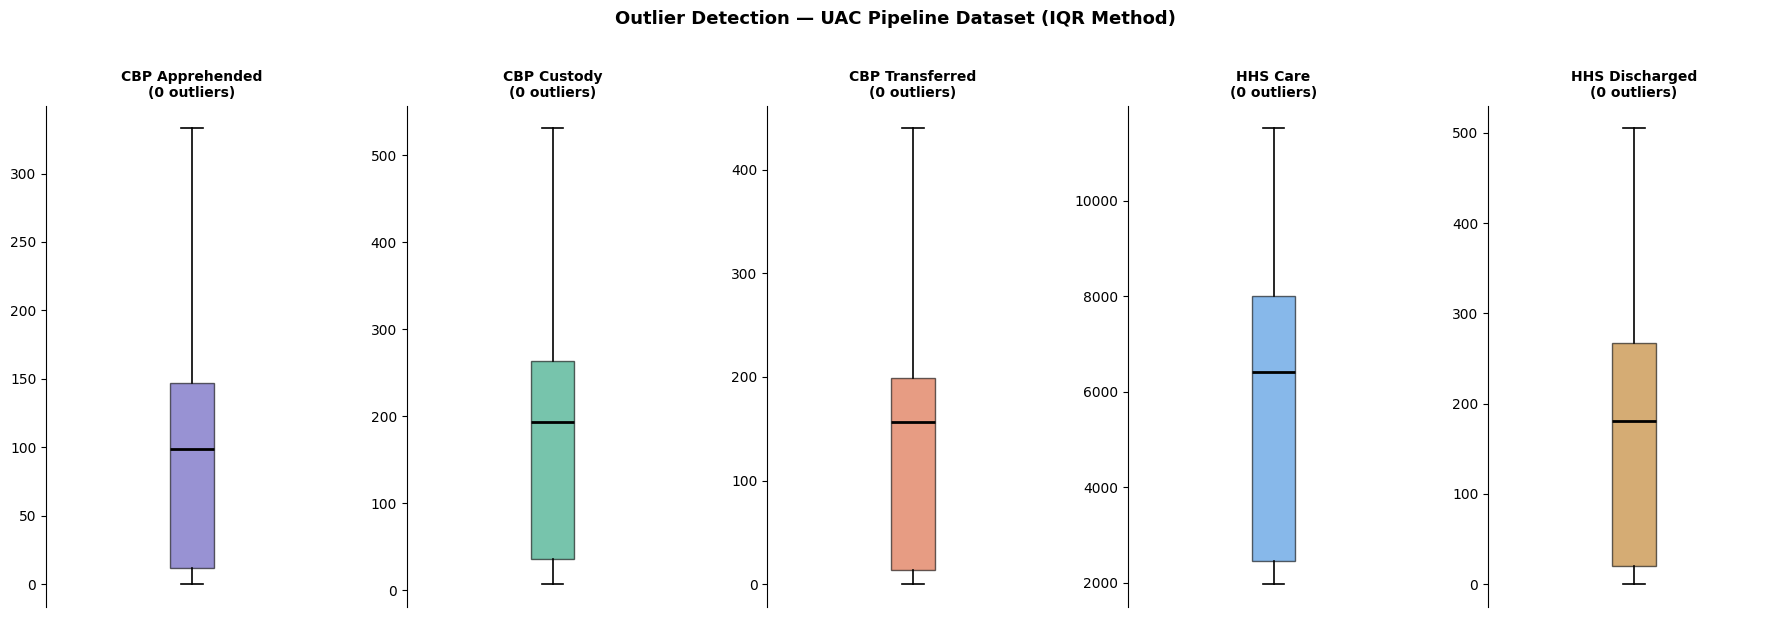

=== OUTLIER DETAILS (IQR METHOD) ===

CBP_Apprehended:
  IQR bounds : [-190.9, 350.1]
  Outliers   : 0 rows

CBP_Custody:
  IQR bounds : [-304.9, 604.1]
  Outliers   : 0 rows

CBP_Transferred:
  IQR bounds : [-263.9, 477.1]
  Outliers   : 0 rows

HHS_Care:
  IQR bounds : [-5846.0, 16324.0]
  Outliers   : 0 rows

HHS_Discharged:
  IQR bounds : [-351.1, 637.9]
  Outliers   : 0 rows



In [20]:
fig, axes = plt.subplots(1, 5, figsize=(18, 6))

numeric_cols = ['CBP_Apprehended', 'CBP_Custody', 'CBP_Transferred',
                'HHS_Care', 'HHS_Discharged']

col_colors = {
    'CBP_Apprehended' : '#534AB7',
    'CBP_Custody'     : '#1D9E75',
    'CBP_Transferred' : '#D85A30',
    'HHS_Care'        : '#378ADD',
    'HHS_Discharged'  : '#BA7517'
}

for i, col in enumerate(numeric_cols):
    ax = axes[i]

    ax.boxplot(
        df[col].dropna(),
        patch_artist=True,
        boxprops=dict(facecolor=col_colors[col], alpha=0.6),
        medianprops=dict(color='black', linewidth=2),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        flierprops=dict(marker='o', markerfacecolor=col_colors[col],
                        markersize=4, alpha=0.5, linestyle='none')
    )

    # Annotate outlier count
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    ax.set_title(f"{col.replace('_', ' ')}\n({len(outliers)} outliers)",
                 fontsize=10, fontweight='bold')
    ax.set_xticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

fig.suptitle('Outlier Detection — UAC Pipeline Dataset (IQR Method)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../assets/charts/02_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

# Print outlier details
print("=== OUTLIER DETAILS (IQR METHOD) ===\n")
for col in numeric_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    low  = Q1 - 1.5 * IQR
    high = Q3 + 1.5 * IQR
    outliers = df[(df[col] < low) | (df[col] > high)]
    print(f"{col}:")
    print(f"  IQR bounds : [{low:.1f}, {high:.1f}]")
    print(f"  Outliers   : {len(outliers)} rows")
    if len(outliers) > 0:
        print(f"  Max outlier: {outliers[col].max():.1f} on {outliers.loc[outliers[col].idxmax(), 'Date'].date()}")
    print()

## Phase 1 — EDA & Data Profiling: Key Findings

### Dataset Health
- **720 valid records** after removing 450 blank padding rows
- **Date range:** January 12, 2023 → December 21, 2025 (1,074 calendar days)
- **Zero missing values** after cleaning
- **29 date gaps** > 3 days — almost all are weekend/holiday skips (normal)
- Notable gaps: 10-day gap at dataset start (Jan 12→22, 2023), 7-day gap in June 2025

### Distribution Insights
- `HHS_Care` shows a **bimodal distribution** — two distinct humps at ~2,500 (2025) 
  and ~7,000–10,000 (2023–24), reflecting a fundamental regime shift in the pipeline
- `CBP_Apprehended` is **right-skewed** — most 2025 days cluster near 0,
  with a long tail from 2023–24 surge days reaching up to 333
- `HHS_Discharged` has a spike at 0 — stagnation days where no placements occurred

### Outlier Analysis
- **0 statistical outliers** detected (IQR method) across all 5 columns
- Extreme values are **real operational events**, not data errors:
  - Max HHS Care = 11,516 (Dec 20, 2023) → record border crossing month
  - Min HHS Discharged = 0 → holiday/stagnation days in 2025

### Weekday Reporting Pattern
- **No Saturday reporting** across 3 years
- **Only 2 Friday records** — reporting almost never done on Fridays
- Sunday has 130 records — reporting does occur on some Sundays

### Records per Year
| Year | Records |
|------|---------|
| 2023 | 230     |
| 2024 | 251     |
| 2025 | 239     |

In [22]:
import os
os.makedirs('../data/processed', exist_ok=True)

df.to_csv('../data/processed/uac_cleaned.csv', index=False)
print("Cleaned dataset saved to ../data/processed/uac_cleaned.csv")
print(f"   Shape: {df.shape}")
print(f"   Columns: {list(df.columns)}")

Cleaned dataset saved to ../data/processed/uac_cleaned.csv
   Shape: (720, 10)
   Columns: ['Date', 'CBP_Apprehended', 'CBP_Custody', 'CBP_Transferred', 'HHS_Care', 'HHS_Discharged', 'Year', 'Month', 'Weekday', 'Date_Gap']
